In [ ]:
import pandas as pd
import numpy as np
import torch
from facenet_pytorch import MTCNN
from PIL import Image
from IPython.display import display
import dlib
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms

def load_fer2013():
    df = pd.read_csv('fer2013.csv')
    images = df['pixels'].apply(lambda x: np.fromstring(x, sep=' ', dtype=np.uint8).reshape(48, 48))
    labels = df['emotion'].values
    usage = df['Usage'].values
    return images, labels, usage


In [ ]:
mtcnn = MTCNN(keep_all=True, device='cuda' if torch.cuda.is_available() else 'cpu')

def detect_face_mtcnn(image):
    face = mtcnn(image)

    if face is not None:
        return face.numpy()
    return None


In [ ]:
detector = dlib.get_frontal_face_detector()

def detect_face_dlib(image):
    dets = detector(image, 1)
    if dets:
        return dets
    return None


In [ ]:
def preprocess_images(images, detector_fn, target_size=(48, 48)):
    processed = []
    failed_count = 0
    for img_path in images:
        img = Image.open(img_path)
        img = np.array(img)
        faces = detector_fn(img)
        if faces is not None:
            processed.append(faces)
        else:
            processed.append(np.zeros(target_size))
            failed_count += 1
    return processed, failed_count

['Group2a/1022547010_caafdb9993_1277_11010857@N03.jpg', 'Group2a/1022861429_e74b96d2cc_1123_8139491@N03.jpg', 'Group2a/1028722345_f0d0fc2aaa_1024_29814666@N00.jpg', 'Group2a/1031480502_6965ddf938_1276_31391002@N00.jpg', 'Group2a/1031605937_c82f4c3b2f_1034_45882256@N00.jpg', 'Group2a/1031994447_0e49d8bc6c_1331_79546572@N00.jpg', 'Group2a/1033352027_b42645b4f6_1394_51035780361@N01.jpg', 'Group2a/1033401878_4649597743_1251_21632841@N00.jpg', 'Group2a/1038878448_07c1d14225_1223_95029059@N00.jpg', 'Group2a/1043472312_7864533c8d_1208_7254887@N02.jpg', 'Group2a/1044928877_d6e20450ba_1186_7439788@N07.jpg', 'Group2a/1045762365_b13f7eb0a0_1271_41432413@N00.jpg', 'Group2a/1045763343_d4d1a40182_1421_41432413@N00.jpg', 'Group2a/1050010039_fe76a9e2ab_1406_25612713@N00.jpg', 'Group2a/1057023681_96f5791804_1391_86204735@N00.jpg', 'Group2a/1057280734_ecb6bbb202_1166_74714402@N00.jpg', 'Group2a/1057882036_7fb6f54f97_1005_86204735@N00.jpg', 'Group2a/1058182672_e1254755ca_1400_91035532@N00.jpg', 'Group2a/

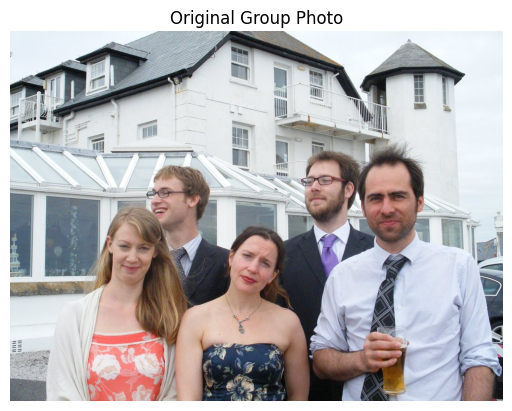

36


In [ ]:
import os
import matplotlib.pyplot as plt

root_dir = 'Group2a/'
images = [os.path.join(root_dir, fname) for fname in sorted(os.listdir(root_dir))
    if fname.lower().endswith(('jpg', 'jpeg', 'png'))
]
print(images)
img_path = images[105]
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.title("Original Group Photo")
plt.show()

In [ ]:
print("Processing with facenet pytorch MTCNN...")
mtcnn_images, mtcnn_failures = preprocess_images(images, detect_face_mtcnn)
print(f"MTCNN Failures: {mtcnn_failures} / {len(images)}")

Processing with facenet pytorch MTCNN...
MTCNN Failures: 0 / 434


In [ ]:
print("Processing with dlib...")
dlib_images, dlib_failures = preprocess_images(images, detect_face_dlib)

print(f"dlib Failures: {dlib_failures} / {len(images)}")

Processing with dlib...
dlib Failures: 36 / 434


### MTCNN Crops and Bounding Boxes

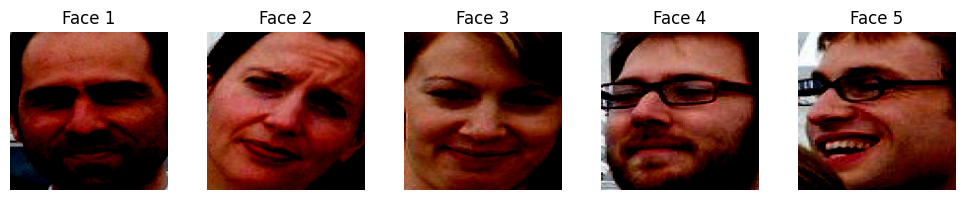

In [ ]:
def show_faces_grid(faces_np):
    num_faces = faces_np.shape[0]
    if num_faces == 0:
        print("No faces to display.")
        return

    faces_for_show = faces_np.transpose(0, 2, 3, 1)
    faces_for_show = np.clip(faces_for_show * 255, 0, 255).astype(np.uint8)

    cols = min(num_faces, 5)
    rows = (num_faces + cols - 1) // cols
    # Show faces
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(num_faces):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(faces_for_show[i])
        plt.axis('off')
        plt.title(f'Face {i + 1}')
    plt.tight_layout()
    plt.show()

show_faces_grid(mtcnn_images[102])

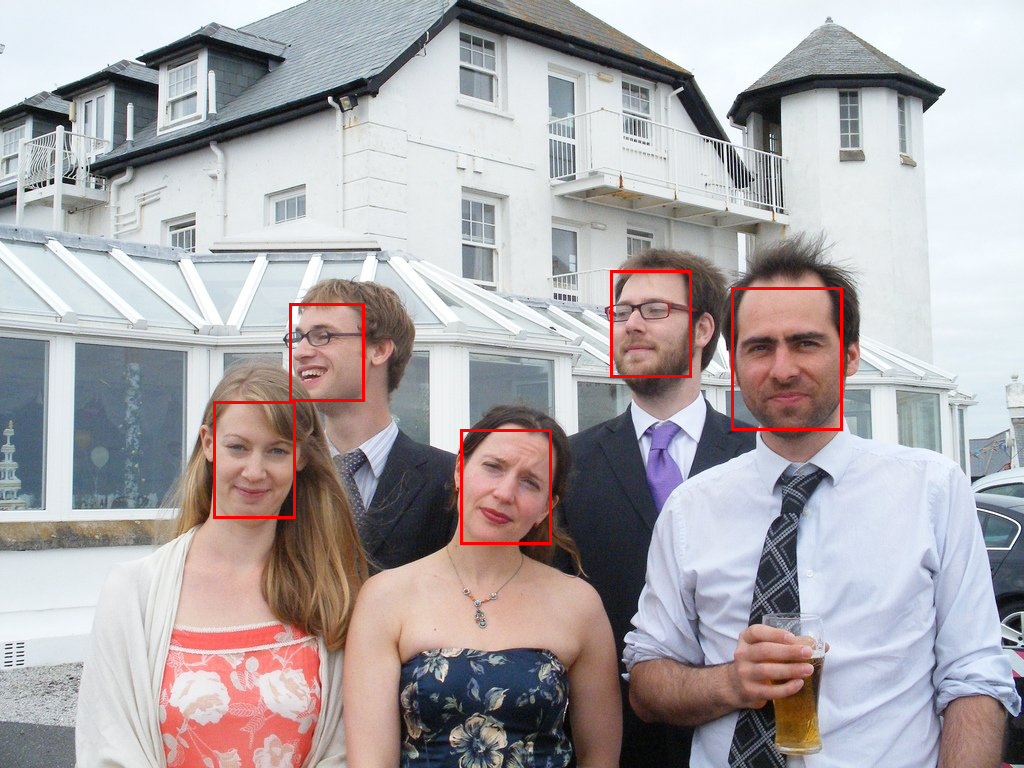

In [ ]:
from PIL import Image, ImageDraw

img_path = images[105]
img = Image.open(img_path)
boxes, probs = mtcnn.detect(img)

# Draw bounding boxes
draw = ImageDraw.Draw(img)
if boxes is not None:
    for box in boxes:
        draw.rectangle(box.tolist(), outline=(255, 0, 0), width=3)

display(img)

### Dlib Crops

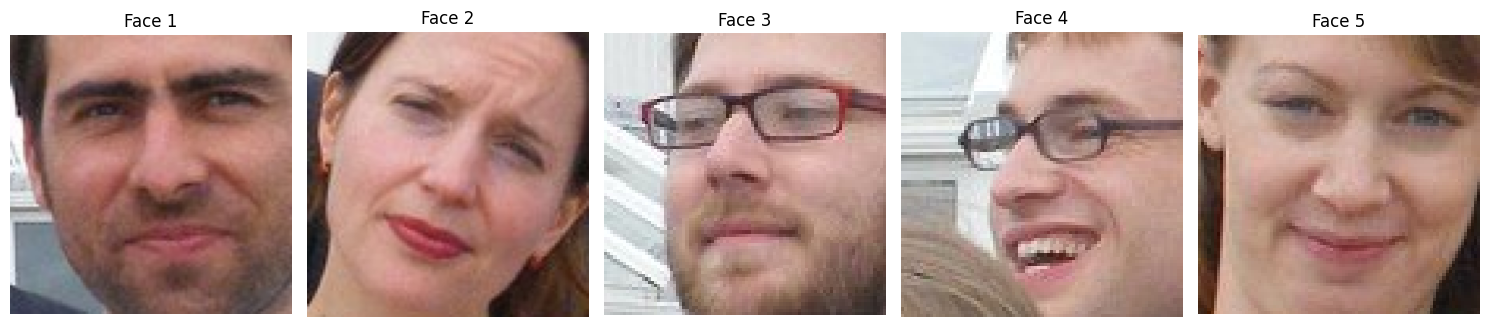

In [ ]:
cropped_faces = []
image = Image.open(img_path)
image = np.array(image)
# Show cropped faces with Dlib face detector
for rect in dlib_images[105]:
    x1, y1, x2, y2 = rect.left(), rect.top(), rect.right(), rect.bottom()
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(image.shape[1], x2), min(image.shape[0], y2)
    cropped_faces.append(image[y1:y2, x1:x2])

if cropped_faces:
    plt.figure(figsize=(3 * len(cropped_faces), 4))
    for i, face in enumerate(cropped_faces):
        plt.subplot(1, len(cropped_faces), i + 1)
        plt.imshow(face)
        plt.axis('off')
        plt.title(f'Face {i+1}')
    plt.show()
else:
    print("No faces detected.")

### CNN with Self-Attention

In [ ]:
# Train dataset
class FERDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.uint8).reshape(48, 48, 1)
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label


In [ ]:
# Custom attention module
class SelfAttention2D(nn.Module):
    def __init__(self, in_channels, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = (in_channels // heads) ** 0.5

        self.qkv = nn.Conv2d(in_channels, in_channels * 3, kernel_size=1)
        self.proj = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(x).reshape(B, 3, self.heads, C // self.heads, H * W)
        q, k, v = qkv[:,0], qkv[:,1], qkv[:,2]

        attn = (q @ k.transpose(-2, -1)) / self.scale
        attn = attn.softmax(dim=-1)

        out = attn @ v
        out = out.reshape(B, C, H, W)
        return self.proj(out)


In [ ]:
# Custom CNN with attention module
class CNNSelfAttentionFER(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.attn = SelfAttention2D(128, heads=4)

        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.attn(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# Data augmentations
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
images, labels, usage = load_fer2013()
train_images = [img for img, u in zip(images, usage) if u == "Training"]
train_labels = [l for l, u in zip(labels, usage) if u == "Training"]
test_images = [img for img, u in zip(images, usage) if u == "PublicTest"]
test_labels = [l for l, u in zip(labels, usage) if u == "PublicTest"]

train_dataset = FERDataset(train_images, train_labels, transform=train_transform)
test_dataset = FERDataset(test_images, test_labels, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNSelfAttentionFER().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_accs, val_accs = [], []
# Training loop
for epoch in range(50):
    model.train()
    correct, total = 0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)
    train_acc = 100. * correct / total
    train_accs.append(train_acc)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    val_acc = 100. * correct / total
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")


Epoch 1: Train Acc=36.38%, Val Acc=45.83%
Epoch 2: Train Acc=46.42%, Val Acc=47.45%
Epoch 3: Train Acc=49.40%, Val Acc=50.49%
Epoch 4: Train Acc=51.68%, Val Acc=51.77%
Epoch 5: Train Acc=53.26%, Val Acc=53.13%
Epoch 6: Train Acc=54.39%, Val Acc=54.89%
Epoch 7: Train Acc=55.69%, Val Acc=55.59%
Epoch 8: Train Acc=56.50%, Val Acc=56.00%
Epoch 9: Train Acc=57.18%, Val Acc=56.37%
Epoch 10: Train Acc=58.07%, Val Acc=56.14%
Epoch 11: Train Acc=58.80%, Val Acc=56.14%
Epoch 12: Train Acc=59.26%, Val Acc=56.62%
Epoch 13: Train Acc=59.98%, Val Acc=58.29%
Epoch 14: Train Acc=60.66%, Val Acc=57.59%
Epoch 15: Train Acc=60.87%, Val Acc=58.34%
Epoch 16: Train Acc=61.37%, Val Acc=59.26%
Epoch 17: Train Acc=62.10%, Val Acc=58.71%
Epoch 18: Train Acc=62.25%, Val Acc=58.99%
Epoch 19: Train Acc=62.86%, Val Acc=59.29%
Epoch 20: Train Acc=63.20%, Val Acc=59.13%
Epoch 21: Train Acc=63.92%, Val Acc=59.49%
Epoch 22: Train Acc=64.06%, Val Acc=59.74%
Epoch 23: Train Acc=64.46%, Val Acc=59.21%
Epoch 24: Train Acc=

KeyboardInterrupt: 

              precision    recall  f1-score   support

           0       0.51      0.51      0.51       467
           1       0.86      0.34      0.49        56
           2       0.46      0.29      0.35       496
           3       0.77      0.83      0.80       895
           4       0.48      0.51      0.49       653
           5       0.68      0.78      0.73       415
           6       0.53      0.57      0.55       607

    accuracy                           0.60      3589
   macro avg       0.61      0.55      0.56      3589
weighted avg       0.59      0.60      0.59      3589



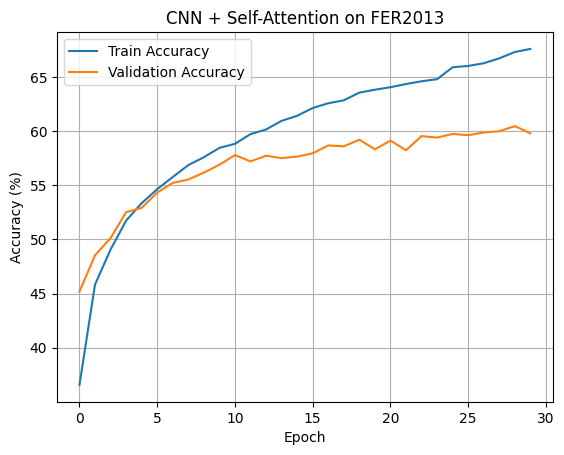

In [ ]:
from sklearn.metrics import classification_report

# Evaluation with custom CNN
all_preds, all_targets = [], []
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

print(classification_report(all_targets, all_preds))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN + Self-Attention on FER2013")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pretrained ResNet18 CNN
class ResNet18FER(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.base_model = models.resnet18(pretrained=pretrained)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
images, labels, usage = load_fer2013()
train_images = [img for img, u in zip(images, usage) if u == "Training"]
train_labels = [l for l, u in zip(labels, usage) if u == "Training"]
test_images = [img for img, u in zip(images, usage) if u == "PublicTest"]
test_labels = [l for l, u in zip(labels, usage) if u == "PublicTest"]

train_dataset = FERDataset(train_images, train_labels, transform=train_transform)
test_dataset = FERDataset(test_images, test_labels, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18FER(pretrained=True).to(device)
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [ ]:
train_accs, val_accs = [], []

# Finetuning loop
for epoch in range(15):
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)
    train_accs.append(100 * correct / total)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    val_accs.append(100 * correct / total)
    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Train Acc={train_accs[-1]:.2f}%, Val Acc={val_accs[-1]:.2f}%")

Epoch 1: Loss=1.7510, Train Acc=43.02%, Val Acc=55.36%
Epoch 2: Loss=1.5323, Train Acc=57.22%, Val Acc=59.49%
Epoch 3: Loss=1.4487, Train Acc=62.56%, Val Acc=60.88%
Epoch 4: Loss=1.3794, Train Acc=66.45%, Val Acc=58.37%
Epoch 5: Loss=1.3323, Train Acc=68.97%, Val Acc=62.89%
Epoch 6: Loss=1.2880, Train Acc=71.68%, Val Acc=64.78%
Epoch 7: Loss=1.2414, Train Acc=74.39%, Val Acc=64.67%
Epoch 8: Loss=1.1968, Train Acc=77.20%, Val Acc=66.59%
Epoch 9: Loss=1.1513, Train Acc=79.55%, Val Acc=65.31%
Epoch 10: Loss=1.1187, Train Acc=81.81%, Val Acc=65.53%


KeyboardInterrupt: 

              precision    recall  f1-score   support

           0       0.58      0.60      0.59       467
           1       0.24      0.73      0.36        56
           2       0.60      0.46      0.52       496
           3       0.91      0.81      0.86       895
           4       0.58      0.54      0.56       653
           5       0.77      0.83      0.80       415
           6       0.56      0.66      0.61       607

    accuracy                           0.66      3589
   macro avg       0.61      0.66      0.61      3589
weighted avg       0.68      0.66      0.66      3589



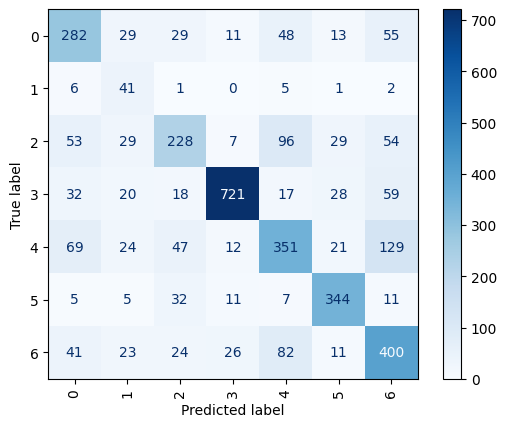

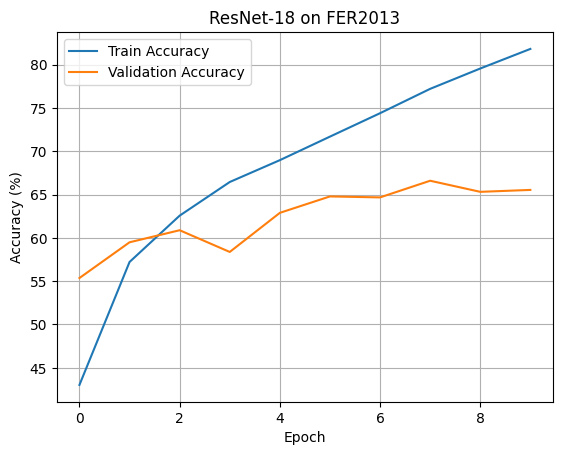

In [ ]:
all_preds, all_targets = [], []
model.eval()
# Evaluation for finetuned ResNet18
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

print(classification_report(all_targets, all_preds))
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.show()

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-18 on FER2013")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"Final Test Accuracy: {val_accs[-1]:.2f}%")

Final Test Accuracy: 65.53%


### Pretrained EfficientNet-B1 CNN

In [ ]:
from torch.utils.data import Dataset
class FER2013Dataset(Dataset):
    def __init__(self, csv_file, usage, transform=None):
        self.data = pd.read_csv(csv_file)
        self.data = self.data[self.data['Usage'] == usage]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pixels = np.fromstring(self.data.iloc[idx]['pixels'], sep=' ', dtype=np.uint8)
        img = pixels.reshape(48, 48)
        img = Image.fromarray(img)
        label = int(self.data.iloc[idx]['emotion'])
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
from torchvision import models, transforms
import torch.nn as nn

# Data augmentations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = FER2013Dataset("fer2013.csv", usage='Training', transform=train_transform)
test_dataset   = FER2013Dataset("fer2013.csv", usage='PublicTest', transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b1(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth
100%|██████████| 30.1M/30.1M [00:00<00:00, 131MB/s]


In [ ]:
from torchvision import models
import torch.nn as nn

# Load pretrained EfficientNetB1 CNN
model = models.efficientnet_b1(pretrained=False)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)

# Load saved model weights
model.load_state_dict(torch.load("efficientnetb1_fer2013_best.pth", map_location='cpu'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)

In [ ]:
from tqdm import tqdm

def evaluate(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

num_epochs = 20
patience = 7
best_val_acc = 0
epochs_no_improve = 0

# Finetune EfficientNet-B1 with early stopping
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    val_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "efficientnetb1_fer2013_best.pth")
        print("Best model saved.")
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

In [ ]:
test_dataset = FER2013Dataset("fer2013.csv", usage='PrivateTest', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7345


In [ ]:
from sklearn.metrics import classification_report
import torch

model.eval()
all_preds = []
all_labels = []

# Evaluate on test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

emotion_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

print(classification_report(all_labels, all_preds, target_names=emotion_labels))


              precision    recall  f1-score   support

       Angry       0.68      0.68      0.68       491
     Disgust       0.85      0.73      0.78        55
        Fear       0.65      0.56      0.60       528
       Happy       0.89      0.92      0.90       879
         Sad       0.59      0.58      0.58       594
    Surprise       0.84      0.86      0.85       416
     Neutral       0.67      0.73      0.70       626

    accuracy                           0.73      3589
   macro avg       0.74      0.72      0.73      3589
weighted avg       0.73      0.73      0.73      3589



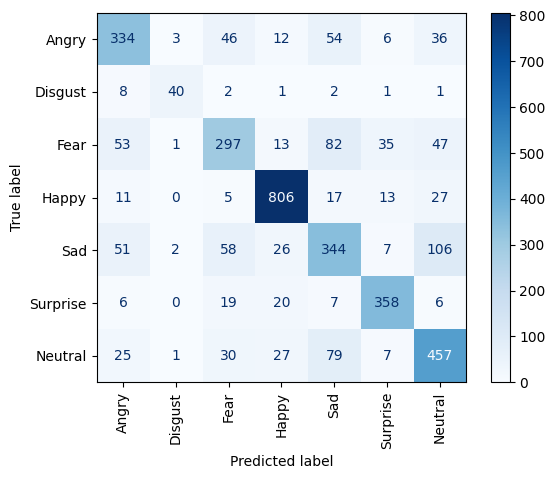

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.show()

### Inference

In [ ]:
emotion_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

In [ ]:
processed_faces = []

# Prepare batches of cropped faces from MTCNN face detector
for i in range(mtcnn_images[15].shape[0]):
    face = mtcnn_images[15][i]

    face = np.transpose(face, (1, 2, 0))
    img_pil = Image.fromarray((face * 255).astype(np.uint8))

    face_tensor = test_transform(img_pil)
    processed_faces.append(face_tensor)

faces_batch = torch.stack(processed_faces).to(device)

In [ ]:
# Run model on batch
with torch.no_grad():
    outputs = model(faces_batch)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, 1)
    print(probs)

tensor([[0.0772, 0.0558, 0.0172, 0.1277, 0.6567, 0.0327, 0.0326],
        [0.1026, 0.0579, 0.0586, 0.5673, 0.1741, 0.0234, 0.0162],
        [0.0191, 0.0148, 0.0141, 0.9070, 0.0100, 0.0193, 0.0157],
        [0.0244, 0.0180, 0.0132, 0.9011, 0.0207, 0.0096, 0.0130],
        [0.0138, 0.0350, 0.0183, 0.1040, 0.0418, 0.0368, 0.7502]],
       device='cuda:0')


In [ ]:
group_profile = np.mean(probs.cpu().numpy(), axis=0)
group_emotion_idx = np.argmax(group_profile)
group_emotion = emotion_labels[group_emotion_idx]
print("Group emotion profile:", group_profile)

Group emotion profile: [0.04740857 0.03631023 0.02429101 0.52143687 0.18066141 0.0243543
 0.16553764]


### Sentiment Score/Entropy

Face 0: Predicted emotion: Sad
Face 1: Predicted emotion: Happy
Face 2: Predicted emotion: Happy
Face 3: Predicted emotion: Happy
Face 4: Predicted emotion: Neutral


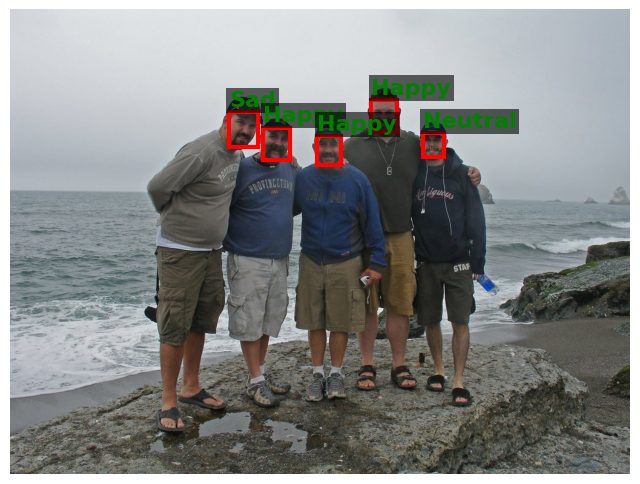

Group main emotion: Happy
Group sentiment score: 0.26
Emotion entropy (diversity): 1.39


In [ ]:
import matplotlib.patches as patches

for i, pred in enumerate(preds):
    print(f"Face {i}: Predicted emotion: {emotion_labels[pred]}")

img = Image.open(images[15])
boxes, probs = mtcnn.detect(img)
labels = [emotion_labels[pred] for pred in preds]

img = np.array(Image.open(images[15]))

# Plot predicted emotion label for each face
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
if boxes is not None:
    for box, label in zip(boxes, labels):
      x1, y1, x2, y2 = box
      rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='red', facecolor='none')
      ax.add_patch(rect)
      ax.text(x1, y1-10, label, color='green', fontsize=16, weight='bold',
              bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=2))

ax.axis('off')
plt.show()

print("Group main emotion:", group_emotion)

# Compute sentiment score and entropy
sentiment_weights = np.array([-1, -1, -0.5, +1, -1, +0.8, 0])
sentiment_score = np.dot(group_profile, sentiment_weights)
print(f"Group sentiment score: {sentiment_score:.2f}")


entropy = -np.sum(group_profile * np.log(group_profile + 1e-8))
print(f"Emotion entropy (diversity): {entropy:.2f}")